In [12]:
import pandas as pd

# df = pd.read_parquet("../data/processed/processed_data.parquet") im just doing this on every notebook

In [13]:
df.shape

(20713, 8)

In [14]:
df.head()

,review_id,review,voted_up,votes_up,review_date,refunded,playtime,language
0,232591722,this game is good yes but if you have a bad wi...,False,0,2026-08-11 16:29:11,False,26.3,en
1,232591709,game crashed when anticheat is launched... spe...,False,0,2026-08-11 16:28:58,False,53.0,en
4,232588494,buggy piece of ♥♥♥♥,False,0,2026-08-11 15:42:16,False,43.0,en
7,232585606,Division 7 versus Division 4 is unfair; it's t...,False,0,2026-08-11 14:58:37,False,93.8,en
9,232584328,"Game dosent run, drops to 10 fps and isnt play...",False,0,2026-08-11 14:39:24,False,3.6,en


In [15]:
(df["voted_up"].value_counts(normalize=True) * 100).round(1)

voted_up
False    57.3
True     42.7
Name: proportion, dtype: float64

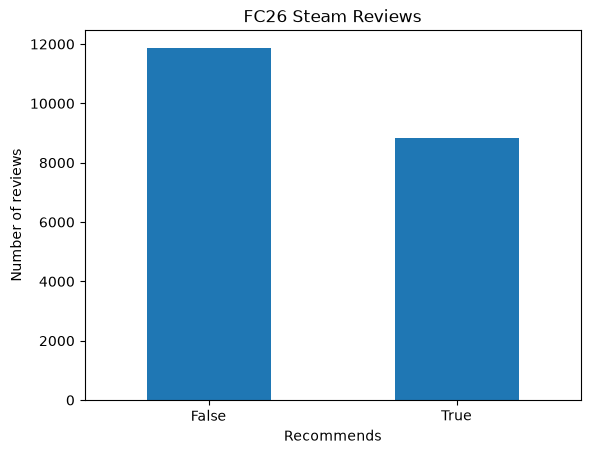

In [16]:
import matplotlib.pyplot as plt

df["voted_up"].value_counts().plot(kind="bar")

plt.title("FC26 Steam Reviews")
plt.ylabel("Number of reviews")
plt.xlabel("Recommends")
plt.xticks(rotation=0)
plt.show()

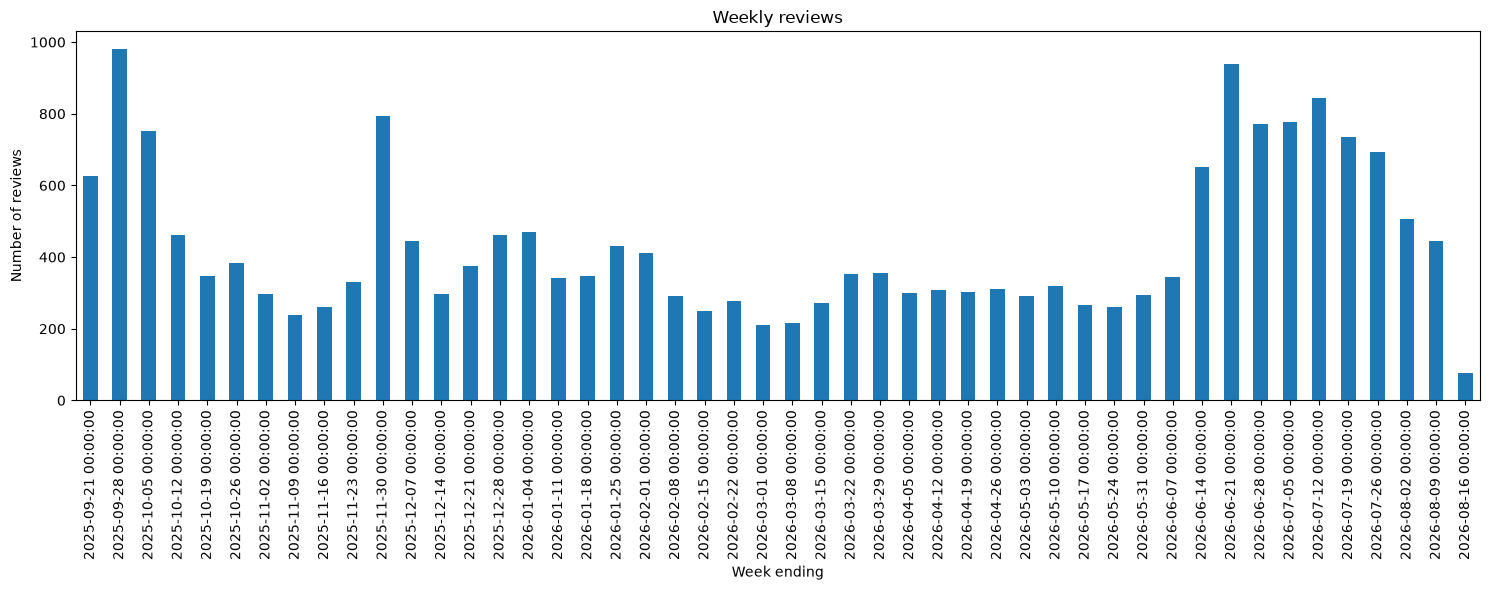

In [22]:
weekly = df.set_index("review_date").resample("W").size()

ax = weekly.plot(kind="bar", figsize=(15, 6))
ax.set_xlabel("Week ending")
ax.set_ylabel("Number of reviews")
ax.set_title("Weekly reviews")
plt.tight_layout()
plt.show()

In [19]:
df['playtime'].describe()

count    20713.000000
mean        75.357404
std        139.209530
min          0.100000
25%          8.600000
50%         27.600000
75%         81.600000
max       2852.000000
Name: playtime, dtype: float64

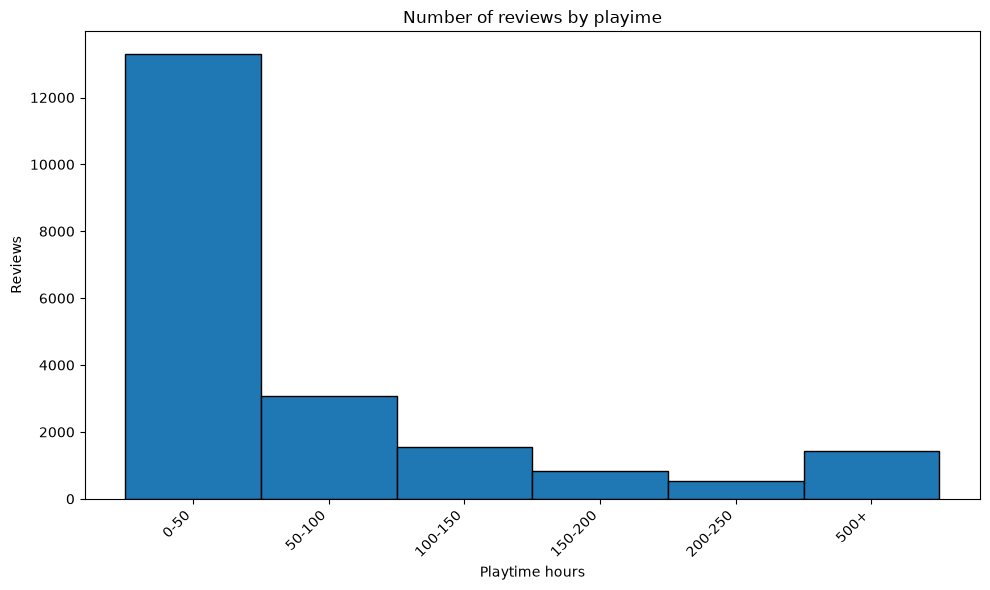

In [21]:
col = df['playtime']  # replace with your actual column name

# 1. define bin edges: 0, 50, 100, ..., 500
bin_edges = list(range(0, 350, 50))  # [0, 50, 100, ..., 500]

# 2. clip values above 500 down to 500 so they all land in the last bin
clipped = col.clip(upper=300)

# 3. plot histogram using these edges
fig, ax = plt.subplots(figsize=(15, 6))
counts, edges, patches = ax.hist(clipped, bins=bin_edges, edgecolor='black')

# 4. fix the x-tick labels so the last bin reads "500+"
labels = [f"{int(edges[i])}-{int(edges[i+1])}" for i in range(len(edges)-1)]
labels[-1] = "500+"

ax.set_xticks([(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)])
ax.set_xticklabels(labels, rotation=45, ha='right')

ax.set_xlabel("Playtime hours")
ax.set_ylabel("Reviews")
ax.set_title("Number of reviews by playime")
plt.tight_layout()
plt.show()

In [23]:
df.sort_values(by="votes_up", ascending=False).head(10)

,review_id,review,voted_up,votes_up,review_date,refunded,playtime,language
20050,214316627,"If you buy the game at full price, you're an i...",False,1447,2025-12-27 07:40:43,False,27.5,en
8849,227902419,"If you're purchasing for the World Cup, DO NOT...",False,1324,2026-06-13 21:41:27,False,1.1,en
28109,205228221,Absolute disgrace of a game. Every single year...,False,725,2025-09-26 10:40:34,False,0.7,en
20391,213992622,EA FC 26 is a straight-up SCAM.\n\nThis is han...,False,723,2025-12-23 11:51:01,False,34.7,en
21784,212505107,Absolute garbage. I refuse to believe actual h...,False,670,2025-12-03 21:51:46,False,5.1,en
27717,205336115,I had a rule where I would wait every other ye...,False,646,2025-09-27 17:46:08,True,1.3,en
9968,226985902,Just wanted to kick a ball around. How hard ca...,False,619,2026-06-02 02:00:03,False,4.0,en
19700,214667052,this game is so bad it made me appreciate time...,True,606,2025-12-30 19:03:27,False,74.7,en
11185,225313253,I mainly play FC 26 for the career mode and ye...,False,452,2026-05-12 01:57:43,False,133.8,en
28251,205185468,The game is basically unplayable on PC. Most o...,False,436,2025-09-25 18:40:11,False,33.8,en


In [25]:
df.sort_values(by="playtime", ascending=False).head(10)

,review_id,review,voted_up,votes_up,review_date,refunded,playtime,language
28583,205005446,(dont ask about my play time i never close thi...,True,0,2025-09-23 04:49:17,False,2852.0,en
10549,226264252,good,True,1,2026-05-23 23:34:22,False,2307.3,so
9870,227116764,cool game. very sweaty,True,0,2026-06-03 21:46:18,False,2139.0,en
3109,230605751,horrible game,False,0,2026-07-16 13:37:27,False,2132.4,en
5295,229512600,"Dear developers of this stupid, pointless game...",False,0,2026-07-03 16:10:46,False,2124.6,en
3668,230335498,Abject filth meant to push even further the co...,False,0,2026-07-12 21:50:51,False,2109.6,en
11370,225079759,BEST GAME 4EVER BUT MY LUCK SO BAD I'M OPEN PA...,True,0,2026-05-09 02:18:56,False,1841.3,en
13570,222474925,bad,False,0,2026-04-04 08:18:08,False,1800.8,so
16336,218393679,this game sucks,False,0,2026-02-15 16:14:04,False,1778.7,en
26636,205842979,its a great game but it has alot of scripting,True,0,2025-10-04 09:58:44,False,1716.0,en
